# Logistic Regression on the Diabetes Dataset
College Machine Learning Lab

**Aim:** Evaluate logistic regression and compare a lower classification threshold and balanced class weights.

Run cells in order. Required packages: pandas, scikit-learn, matplotlib, seaborn and Jupyter. Use a local `diabetes.csv` beside the notebook, or an internet connection for the online fallback.

## 1. Import the required libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

sns.set_theme(style="whitegrid")

## 2. Load diabetes.csv
Use the local file when present. Otherwise, read [Plotly's diabetes CSV](https://github.com/plotly/datasets/blob/master/diabetes.csv) directly without saving an extra file. Outcome: 0 = no diabetes, 1 = diabetes.

In [2]:
data_path = Path("diabetes.csv")
if data_path.exists():
    df = pd.read_csv(data_path)
    print("Loaded local diabetes.csv")
else:
    url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
    df = pd.read_csv(url)
    print("Local diabetes.csv not found; loaded online diabetes.csv")

Loaded local diabetes.csv


## 3. Inspect the dataset

In [3]:
display(df.head())
print("Shape:", df.shape)
print("\nNull values per column:")
print(df.isnull().sum())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Shape: (768, 9)

Null values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 4. Separate input features and target
Keep the CSV values unchanged for this simple experiment. Zero entries are not counted as null values; investigating implausible zero measurements would be a separate preprocessing experiment.

In [4]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass counts:")
print(y.value_counts().sort_index())

Input shape: (768, 8)
Target shape: (768,)

Class counts:
Outcome
0    500
1    268
Name: count, dtype: int64


## 5. Split into 80% training and 20% testing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 614
Testing rows: 154


## 6. Standardize input features
Fit the scaler only on training data to prevent test data leakage. Transform test data using the same scaler.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Train the normal Logistic Regression model

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

## 8. Predict the test data

In [8]:
y_pred = model.predict(X_test_scaled)
y_probability = model.predict_proba(X_test_scaled)[:, 1]
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [0 0 0 0 0 0 0 1 1 0]


## 9. Evaluate the normal model
Diabetes (Outcome = 1) is the positive class. Reuse this small function to calculate the four metrics for each experiment.

In [9]:
def get_metrics(y_true, y_prediction):
    return {
        "Accuracy": accuracy_score(y_true, y_prediction),
        "Precision": precision_score(y_true, y_prediction, zero_division=0),
        "Recall": recall_score(y_true, y_prediction, zero_division=0),
        "F1 score": f1_score(y_true, y_prediction, zero_division=0)
    }

normal_metrics = get_metrics(y_test, y_pred)
for metric, value in normal_metrics.items():
    print(f"{metric}: {value:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("\nConfusion matrix (rows = actual, columns = predicted):")
print(cm)

Accuracy: 0.7987
Precision: 0.7447
Recall: 0.6481
F1 score: 0.6931

Confusion matrix (rows = actual, columns = predicted):
[[88 12]
 [19 35]]


## 10. Plot the confusion matrix

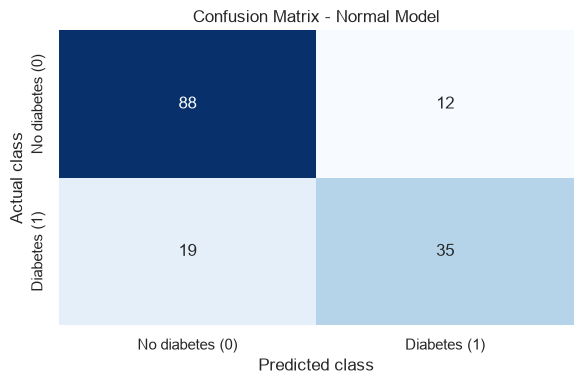

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No diabetes (0)", "Diabetes (1)"],
    yticklabels=["No diabetes (0)", "Diabetes (1)"]
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix - Normal Model")
plt.tight_layout()
plt.show()

## 11. Plot the ROC curve and calculate AUC
Use predicted probabilities for ROC and AUC. The curve shows true positive rate versus false positive rate across classification thresholds.

AUC score: 0.8596


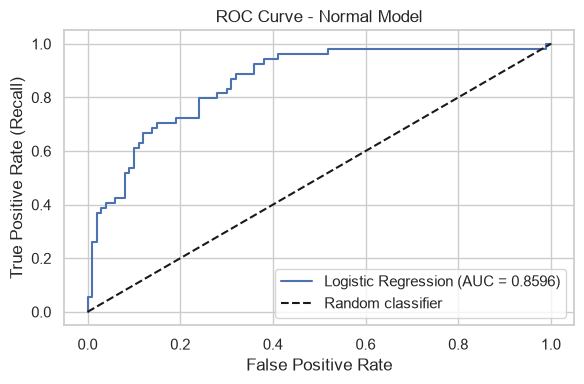

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)
auc_score = roc_auc_score(y_test, y_probability)
print(f"AUC score: {auc_score:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Normal Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Experiment 1: Change the threshold to 0.3
The normal model uses a threshold of 0.5. Classify a sample as positive when its predicted probability is at least 0.3. Reuse the trained model without retraining. A lower threshold generally increases recall and may reduce precision.

In [12]:
y_pred_03 = (y_probability >= 0.3).astype(int)
threshold_metrics = get_metrics(y_test, y_pred_03)

threshold_comparison = pd.DataFrame(
    [normal_metrics, threshold_metrics],
    index=["Normal (threshold 0.5)", "Normal (threshold 0.3)"]
)
display(threshold_comparison.round(4))
print("Change from threshold 0.5 to 0.3 (percentage points):")
display(((threshold_comparison.iloc[1] - threshold_comparison.iloc[0]) * 100).round(2))

,Accuracy,Precision,Recall,F1 score
Normal (threshold 0.5),0.7987,0.7447,0.6481,0.6931
Normal (threshold 0.3),0.7532,0.6143,0.7963,0.6935


Change from threshold 0.5 to 0.3 (percentage points):


Accuracy     -4.55
Precision   -13.04
Recall       14.81
F1 score      0.05
dtype: float64

## 13. Experiment 2: Use balanced class weights
`class_weight='balanced'` gives greater weight to the less frequent training class. Use the same split and scaled features, with threshold 0.5.

In [13]:
balanced_model = LogisticRegression(max_iter=1000, class_weight="balanced")
balanced_model.fit(X_train_scaled, y_train)
y_pred_balanced = balanced_model.predict(X_test_scaled)
balanced_metrics = get_metrics(y_test, y_pred_balanced)

comparison = pd.DataFrame(
    [normal_metrics, threshold_metrics, balanced_metrics],
    index=["Normal (threshold 0.5)", "Normal (threshold 0.3)",
           "Balanced (threshold 0.5)"]
)
display(comparison.round(4))

,Accuracy,Precision,Recall,F1 score
Normal (threshold 0.5),0.7987,0.7447,0.6481,0.6931
Normal (threshold 0.3),0.7532,0.6143,0.7963,0.6935
Balanced (threshold 0.5),0.7662,0.6500,0.7222,0.6842


## 14. Conclusion
This short summary uses the actual results of the current run.

In [14]:
recall_change = 100 * (threshold_metrics["Recall"] - normal_metrics["Recall"])
precision_change = 100 * (threshold_metrics["Precision"] - normal_metrics["Precision"])
best_f1 = comparison["F1 score"].idxmax()

display(Markdown(
    f"The normal model achieved **{normal_metrics['Accuracy']:.2%} accuracy**, "
    f"**{normal_metrics['Recall']:.2%} recall** and **{auc_score:.4f} ROC AUC**. "
    f"Lowering the threshold to 0.3 changed recall by **{recall_change:+.2f}** "
    f"and precision by **{precision_change:+.2f} percentage points**. "
    f"The balanced model achieved **{balanced_metrics['Accuracy']:.2%} accuracy** "
    f"and **{balanced_metrics['Recall']:.2%} recall**. "
    f"**{best_f1}** had the highest F1 score on this split "
    f"(**{comparison['F1 score'].max():.4f}**). "
    "These experiments illustrate the trade-off between detecting positive cases and false alarms. "
    "Results are specific to this split; selecting a threshold for future use requires separate validation data."
))

The normal model achieved **79.87% accuracy**, **64.81% recall** and **0.8596 ROC AUC**. Lowering the threshold to 0.3 changed recall by **+14.81** and precision by **-13.04 percentage points**. The balanced model achieved **76.62% accuracy** and **72.22% recall**. **Normal (threshold 0.3)** had the highest F1 score on this split (**0.6935**). These experiments illustrate the trade-off between detecting positive cases and false alarms. Results are specific to this split; selecting a threshold for future use requires separate validation data.